In [1]:
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.transforms.functional as TF
import torchvision.models as models

from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

from ultralytics import YOLO

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f"Device : {DEVICE}")

# Config 
CFG = dict(
    # Data
    lol_root      = './LOL',          # path to LOL dataset root
    crop_size     = 256,              # training crop size

    # Model
    base_ch       = 32,               # LLEN base channels (32 → 32/64/128/256)
    yolo_weights  = 'yolov8n.pt',     # YOLOv8n weights (auto-download)

    # Training
    epochs        = 200,              # total epochs (was 3 for test)
    batch_size    = 4,                # images per batch (reduce to 2 if OOM)
    lr            = 1e-4,             # learning rate
    lambda_perc   = 0.1,              # perceptual loss weight
    lambda_det    = 0.5,              # max detection loss weight (ramped from 0)
    val_every     = 5,                # validate every N epochs
    num_workers   = 0,                # set 0 for Jupyter on Mac/Windows

    # Paths
    ckpt_dir      = './checkpoints',  # where to save best.pt and epoch_*.pt
)

Path(CFG['ckpt_dir']).mkdir(parents=True, exist_ok=True)
print("Config OK")

Device : mps
Config OK


In [2]:
class LOLDataset(Dataset):
    """
    Paired (low-light, normal-light) loader for the LOL dataset.

    LOL structure:
        LOL/
        ├── our485/low/   our485/high/   (485 train pairs)
        └── eval15/low/   eval15/high/   (15 val pairs)

    Download: https://drive.google.com/file/d/157bjO1_cFoSJ2FapgwwPM4I2beZlYXoO
    """
    SPLIT_DIRS = {'train': 'our485', 'val': 'eval15'}
    _IMG_EXTS  = {'.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff'}

    def __init__(self, root, split='train', crop_size=256, augment=True):
        assert split in self.SPLIT_DIRS
        self.crop_size = crop_size
        self.augment   = augment and (split == 'train')

        base          = Path(root) / self.SPLIT_DIRS[split]
        self.low_dir  = base / 'low'
        self.high_dir = base / 'high'

        for d in (self.low_dir, self.high_dir):
            if not d.is_dir():
                raise FileNotFoundError(f"Not found: {d}")

        self.filenames = sorted(
            f for f in os.listdir(self.low_dir)
            if Path(f).suffix.lower() in self._IMG_EXTS
        )
        missing = [f for f in self.filenames if not (self.high_dir / f).exists()]
        if missing:
            raise FileNotFoundError(f"Missing high images: {missing[:3]}")

        self.to_tensor = T.ToTensor()

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname    = self.filenames[idx]
        low_img  = Image.open(self.low_dir  / fname).convert('RGB')
        high_img = Image.open(self.high_dir / fname).convert('RGB')

        if self.crop_size is not None:
            low_img, high_img = self._paired_crop(low_img, high_img)

        if self.augment and random.random() > 0.5:
            low_img  = TF.hflip(low_img)
            high_img = TF.hflip(high_img)

        return self.to_tensor(low_img), self.to_tensor(high_img), fname

    def _paired_crop(self, low, high):
        w, h = low.size
        c    = self.crop_size
        if w < c or h < c:
            return TF.resize(low, [c, c]), TF.resize(high, [c, c])
        top  = random.randint(0, h - c)
        left = random.randint(0, w - c)
        return TF.crop(low, top, left, c, c), TF.crop(high, top, left, c, c)


def get_loaders(cfg):
    train_set = LOLDataset(cfg['lol_root'], 'train', cfg['crop_size'], augment=True)
    val_set   = LOLDataset(cfg['lol_root'], 'val',   None,            augment=False)

    train_loader = DataLoader(train_set, batch_size=cfg['batch_size'],
                              shuffle=True,  num_workers=cfg['num_workers'],
                              drop_last=True,  pin_memory=False)
    val_loader   = DataLoader(val_set,   batch_size=1,
                              shuffle=False, num_workers=cfg['num_workers'],
                              drop_last=False, pin_memory=False)
    return train_loader, val_loader


# Quick check
train_loader, val_loader = get_loaders(CFG)
low, high, fnames = next(iter(train_loader))
print(f"Train: {len(train_loader.dataset)} pairs | Val: {len(val_loader.dataset)} pairs")
print(f"Batch low={tuple(low.shape)}  high={tuple(high.shape)}  range=[{low.min():.2f},{low.max():.2f}]")

Train: 485 pairs | Val: 15 pairs
Batch low=(4, 3, 256, 256)  high=(4, 3, 256, 256)  range=[0.00,0.47]


In [3]:
# ── Building blocks ───────────────────────────────────────────────────────────
import torch.nn.functional as F
class ResBlock(nn.Module):
    """Two-layer residual block. Keeps spatial size."""
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(True),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU(True)

    def forward(self, x):
        return self.relu(x + self.block(x))


class EncoderBlock(nn.Module):
    """Conv → ResBlock → (skip, downsampled)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.res  = ResBlock(out_ch)
        self.down = nn.MaxPool2d(2)

    def forward(self, x):
        x    = self.res(self.conv(x))
        skip = x
        return self.down(x), skip


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, feedback_ch=32):
        super().__init__()
        self.merge = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
        self.res = ResBlock(out_ch)
        if feedback_ch is not None:
            self.feedback_proj = nn.Conv2d(feedback_ch, out_ch, 1, bias=False)
        else:
            self.feedback_proj = None

    def forward(self, x, skip, feedback=None):
        x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = self.merge(torch.cat([x, skip], dim=1))
        if feedback is not None and self.feedback_proj is not None:
            if feedback.shape[-2:] != x.shape[-2:]:
                feedback = F.interpolate(feedback, size=x.shape[-2:],
                                         mode='bilinear', align_corners=False)
            x = x + self.feedback_proj(feedback)   # ← actually use the proj
        return self.res(x)


# ── Full network ──────────────────────────────────────────────────────────────

class LLEN(nn.Module):

    def __init__(self, base_ch=32):
        super().__init__()
        c = base_ch

        self.enc1 = EncoderBlock(3,   c)      # skip: (B,  c,  H,   W)
        self.enc2 = EncoderBlock(c,   c*2)    # skip: (B, 2c, H/2, W/2)
        self.enc3 = EncoderBlock(c*2, c*4)    # skip: (B, 4c, H/4, W/4)
        self.enc4 = EncoderBlock(c*4, c*8)    # skip: (B, 8c, H/8, W/8)

        self.bottleneck = nn.Sequential(ResBlock(c*8), ResBlock(c*8))

        self.dec4 = DecoderBlock(c*8, c*8, c*4, feedback_ch=c*4)  # P5 → 128ch
        self.dec3 = DecoderBlock(c*4, c*4, c*2, feedback_ch=c*2)  # P4 → 64ch
        self.dec2 = DecoderBlock(c*2, c*2, c,   feedback_ch=c)    # P3 → 32ch
        self.dec1 = DecoderBlock(c,   c,   c,   feedback_ch=None)  # no injection

        self.head = nn.Sequential(
            nn.Conv2d(c, c, 3, padding=1, bias=False), nn.ReLU(True),
            nn.Conv2d(c, 3, 1), nn.Sigmoid(),
        )

    def forward(self, x, dgff_p5=None, dgff_p4=None, dgff_p3=None):
        x, s1 = self.enc1(x)
        x, s2 = self.enc2(x)
        x, s3 = self.enc3(x)
        x, s4 = self.enc4(x)
        x     = self.bottleneck(x)
        x     = self.dec4(x, s4, feedback=dgff_p5)
        x     = self.dec3(x, s3, feedback=dgff_p4)
        x     = self.dec2(x, s2, feedback=dgff_p3)   
        x     = self.dec1(x, s1)                      
        return self.head(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Smoke test
llen_test = LLEN(CFG['base_ch'])
dummy     = torch.rand(1, 3, 256, 256)
out       = llen_test(dummy)
assert out.shape == dummy.shape and out.min() >= 0 and out.max() <= 1
print(f"LLEN params: {llen_test.count_parameters():,}")
print(f"LLEN forward: {tuple(dummy.shape)} → {tuple(out.shape)}  ✓")
del llen_test, dummy, out

LLEN params: 4,844,803
LLEN forward: (1, 3, 256, 256) → (1, 3, 256, 256)  ✓


In [4]:
"""
dgff_v2.py — DGFF Module with Channel Gating
=============================================
... (docstring unchanged)
"""

import torch
import torch.nn as nn
from ultralytics import YOLO


class GatedAdapter(nn.Module):
    """ ... (unchanged) ... """
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.gate = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, f_det, target_size):
        f_det = nn.functional.interpolate(
            f_det, size=target_size, mode='bilinear', align_corners=False
        )
        return self.gate(f_det) * self.proj(f_det)


class DGFFModule(nn.Module):


    def __init__(
        self,
        yolo_weights: str = 'yolov8n.pt',
        llen_base_ch: int = 32,
        freeze_backbone: bool = True,
    ):
        super().__init__()

        # Load YOLOv8 backbone (first 10 layers = up to P5)
        yolo = YOLO(yolo_weights)
        self.backbone = yolo.model.model[:10]

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad_(False)

        # Probe actual channel depths
        with torch.no_grad():
            probe = torch.zeros(1, 3, 64, 64)
            out = probe
            for i, layer in enumerate(self.backbone):
                out = layer(out)
                if i == 4:
                    actual_p3 = out.shape[1]
                if i == 6:
                    actual_p4 = out.shape[1]
                if i == 9:
                    actual_p5 = out.shape[1]
        self.p3_ch = actual_p3
        self.p4_ch = actual_p4
        self.p5_ch = actual_p5

        # Build gated adapters
        c = llen_base_ch
        self._llen_base_ch = c
        self.adapter_p3 = GatedAdapter(self.p3_ch, c)
        self.adapter_p5 = GatedAdapter(self.p5_ch, c * 4)   # P5 -> dec4 (128ch)
        self.adapter_p4 = GatedAdapter(self.p4_ch, c * 2)   # P4 -> dec3 (64ch)

    def forward(self, enhanced_img):
    
        x = enhanced_img
        p4_raw = None
        p5_raw = None

        for i, layer in enumerate(self.backbone):
            x = layer(x)
            if i == 4:
                p3_raw = x
            if i == 6:
                p4_raw = x
            if i == 9:
                p5_raw = x

        if p3_raw is None or p4_raw is None or p5_raw is None:
            raise RuntimeError("Could not extract P4/P5 from backbone. Check layer indices.")

        c = self._llen_base_ch
        H_input, W_input = enhanced_img.shape[-2:]

        p5_size = (H_input // 8, W_input // 8)   # dec4 spatial size
        p4_size = (H_input // 4, W_input // 4)   # dec3 spatial size
        p3_size = (H_input // 2, W_input // 2)

        p5_feedback = self.adapter_p5(p5_raw, p5_size)
        p4_feedback = self.adapter_p4(p4_raw, p4_size)
        p3_feedback = self.adapter_p3(p3_raw, p3_size)

        return p4_feedback, p5_feedback, p3_feedback

    def count_parameters(self):
        total = sum(p.numel() for p in self.parameters())
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total, trainable



# Smoke test


if __name__ == '__main__':
    import sys

    print("DGFFv2 Smoke Test")
    device = torch.device('cpu')

    try:
        dgff = DGFFModule(yolo_weights='yolov8n.pt', llen_base_ch=32).to(device)
    except Exception as e:
        print(f"[SKIP] Could not load YOLOv8: {e}")
        sys.exit(0)

    total, trainable = dgff.count_parameters()
    print(f"  Params total / trainable: {total:,} / {trainable:,}")

    dummy = torch.rand(2, 3, 256, 256)
    p4, p5, p3 = dgff(dummy)
    print(f"  P4 feedback shape: {tuple(p4.shape)}  (expected: 2,  64,  64,  64)")
    print(f"  P5 feedback shape: {tuple(p5.shape)}  (expected: 2, 128,  32,  32)")
    print(f"  P3 feedback shape: {tuple(p3.shape)}  (expected: 2,  64, 128, 128)")
    print("  Smoke test passed ✓")

DGFFv2 Smoke Test
  Params total / trainable: 1,359,120 / 86,464
  P4 feedback shape: (2, 64, 64, 64)  (expected: 2,  64,  64,  64)
  P5 feedback shape: (2, 128, 32, 32)  (expected: 2, 128,  32,  32)
  P3 feedback shape: (2, 32, 128, 128)  (expected: 2,  64, 128, 128)
  Smoke test passed ✓


In [5]:
# ── Perceptual Loss (VGG-16 relu2_2 + relu3_3) ───────────────────────────────

class PerceptualLoss(nn.Module):
    """Feature matching loss on VGG-16 intermediate activations."""
    def __init__(self, device):
        super().__init__()
        vgg          = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.slice1  = nn.Sequential(*list(vgg)[:10]).to(device).eval()
        self.slice2  = nn.Sequential(*list(vgg)[:17]).to(device).eval()
        for p in self.parameters(): p.requires_grad_(False)

        mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1,3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1,3,1,1)
        self.register_buffer('mean', mean)
        self.register_buffer('std',  std)

    def forward(self, pred, target):
        pred   = (pred   - self.mean) / self.std
        target = (target - self.mean) / self.std
        return F.mse_loss(self.slice1(pred), self.slice1(target)) + \
               F.mse_loss(self.slice2(pred), self.slice2(target))


# ── Detection Feature Loss ────────────────────────────────────────────────────

class DetectionFeatureLoss(nn.Module):
    """
    Core detection-guidance loss.  Minimises the L2 distance between
    YOLOv8 backbone features extracted from (a) the DGFF-guided enhanced
    image and (b) the clean normal-light reference.

    Interpretation: if the enhancer produces the same internal detector
    activations as the clean image, the detector will fire identically
    on both — which is exactly the task-oriented objective.

    Why this instead of pseudo-label box loss:
      - LOL has no detection annotations
      - Feature-level loss gives dense gradients (not sparse bbox regression)
      - No threshold or NMS tuning required
      - Gradient flows cleanly: backbone → DGFF adapters → LLEN decoder

    Shares the backbone from DGFFModule — no extra memory.
    """
    def __init__(self, dgff_module):
        super().__init__()
        self.backbone = dgff_module.backbone   # shared, already frozen or not

    def _extract(self, x, no_grad=False):
        feats = []
        ctx   = torch.no_grad() if no_grad else torch.enable_grad()
        with ctx:
            for i, layer in enumerate(self.backbone):
                x = layer(x)
                if i in (4, 6, 9):    # P3, P4 and P5
                    feats.append(x)
        return feats

    def forward(self, enhanced_guided, high):
        feats_enh   = self._extract(enhanced_guided, no_grad=False)
        feats_clean = self._extract(high,            no_grad=True)
        loss = sum(F.mse_loss(fe, fc.detach())
                   for fe, fc in zip(feats_enh, feats_clean))
        return loss


# ── Metrics ───────────────────────────────────────────────────────────────────

def compute_psnr(pred, target):
    mse = F.mse_loss(pred, target).item()
    return float('inf') if mse == 0 else 10 * torch.log10(torch.tensor(1.0 / mse)).item()

def compute_ssim(pred, target):
    try:
        from pytorch_msssim import ssim
        return ssim(pred, target, data_range=1.0).item()
    except ImportError:
        mu1, mu2 = pred.mean(), target.mean()
        s1, s2   = pred.std(),  target.std()
        s12      = ((pred - mu1) * (target - mu2)).mean()
        C1, C2   = 0.01**2, 0.03**2
        return (((2*mu1*mu2+C1)*(2*s12+C2)) / ((mu1**2+mu2**2+C1)*(s1**2+s2**2+C2))).item()

print("Loss functions defined ✓")

Loss functions defined ✓


In [6]:
llen = LLEN(base_ch=CFG['base_ch']).to(DEVICE)
dgff = DGFFModule(
    yolo_weights    = CFG['yolo_weights'],
    llen_base_ch    = CFG['base_ch'],
    freeze_backbone = True,
).to(DEVICE)

perc_loss = PerceptualLoss(DEVICE)
det_loss  = DetectionFeatureLoss(dgff).to(DEVICE)
l1_loss   = nn.L1Loss()

# Optimise LLEN + adapter layers; backbone stays frozen
trainable = (
    list(llen.parameters()) +
    list(dgff.adapter_p3.parameters()) +
    list(dgff.adapter_p4.parameters()) +
    list(dgff.adapter_p5.parameters())
)
optimiser = Adam(trainable, lr=CFG['lr'], betas=(0.9, 0.999))
scheduler = CosineAnnealingLR(optimiser, T_max=CFG['epochs'], eta_min=1e-6)

tot, tr = dgff.count_parameters()
print(f"LLEN params         : {llen.count_parameters():,}")
print(f"DGFF total/trainable: {tot:,} / {tr:,}")
print(f"Optimiser params    : {sum(p.numel() for p in trainable):,}")

LLEN params         : 4,844,803
DGFF total/trainable: 1,359,120 / 86,464
Optimiser params    : 4,931,267


In [7]:
import torch
from pathlib import Path
from ultralytics import YOLO

# Device (CPU for your Mac Mini)
DEVICE = torch.device('cpu')  # or 'mps' if you have MPS, but you used CPU mostly

# Load your models
ckpt = torch.load(Path(CFG['ckpt_dir']) / 'best.pt', map_location=DEVICE)
llen.load_state_dict(ckpt['llen_state'])
dgff.load_state_dict(ckpt['dgff_state'])

# Load validation data (same as in original)
_, val_loader = get_loaders(CFG)  # from your dataset class

In [10]:
import time
import torch.nn as nn

def measure_inference_time(model_or_callable, input_tensor, num_runs=100, warmup=20):
    # If it's a torch module, put it in eval mode
    if isinstance(model_or_callable, nn.Module):
        model_or_callable.eval()
    with torch.no_grad():
        for _ in range(warmup):
            _ = model_or_callable(input_tensor)
        start = time.perf_counter()
        for _ in range(num_runs):
            _ = model_or_callable(input_tensor)
        end = time.perf_counter()
    return (end - start) * 1000 / num_runs

# Move models to CPU (or whichever device you use)
DEVICE = 'cpu'
llen = llen.to(DEVICE)
dgff = dgff.to(DEVICE)
dummy = torch.rand(1, 3, 256, 256).to(DEVICE)

# LLEN only
time_llen = measure_inference_time(llen, dummy)

# Full pipeline (training only) – defined as a function
def full_pipeline(x):
    enhanced = llen(x)
    p4, p5, p3 = dgff(enhanced)
    return llen(x, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

# Measure full pipeline – now works because the function is not a module
time_full = measure_inference_time(full_pipeline, dummy)

print(f"Inference time (ms per 256×256 image):")
print(f"  LLEN only: {time_llen:.2f} ms")
print(f"  Full pipeline (training): {time_full:.2f} ms")
print(f"  Overhead at inference: {(time_full - time_llen) / time_llen * 100:.1f}%")

Inference time (ms per 256×256 image):
  LLEN only: 113.72 ms
  Full pipeline (training): 248.22 ms
  Overhead at inference: 118.3%


In [11]:
from thop import profile

input_tensor = torch.randn(1, 3, 256, 256).to(DEVICE)
flops, params = profile(llen, inputs=(input_tensor,))
print(f"LLEN FLOPs: {flops/1e9:.2f} G, Params: {params/1e6:.2f} M")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
LLEN FLOPs: 9.54 G, Params: 4.82 M


In [12]:
from ultralytics import YOLO

# Load YOLOv8 detector (pre‑trained on COCO)
detector = YOLO('yolov8n.pt')

# Function to compute mAP per class on ExDark
def compute_per_class_ap(model, loader, detector):
    model.eval()
    # You'll need to collect detection results and ground truth
    # This is dataset‑specific; you can adapt the validation loop from your paper.
    # For brevity, we outline the idea:
    class_aps = {}
    for low, high, fname in loader:
        low = low.to(DEVICE)
        enhanced = model(low)  # or full pipeline if you want DGFF
        # Run detector on enhanced
        results = detector(enhanced)
        # Accumulate metrics per class (use COCO evaluation or custom code)
        # ...
    return class_aps

# Compute for LLEN and for raw images

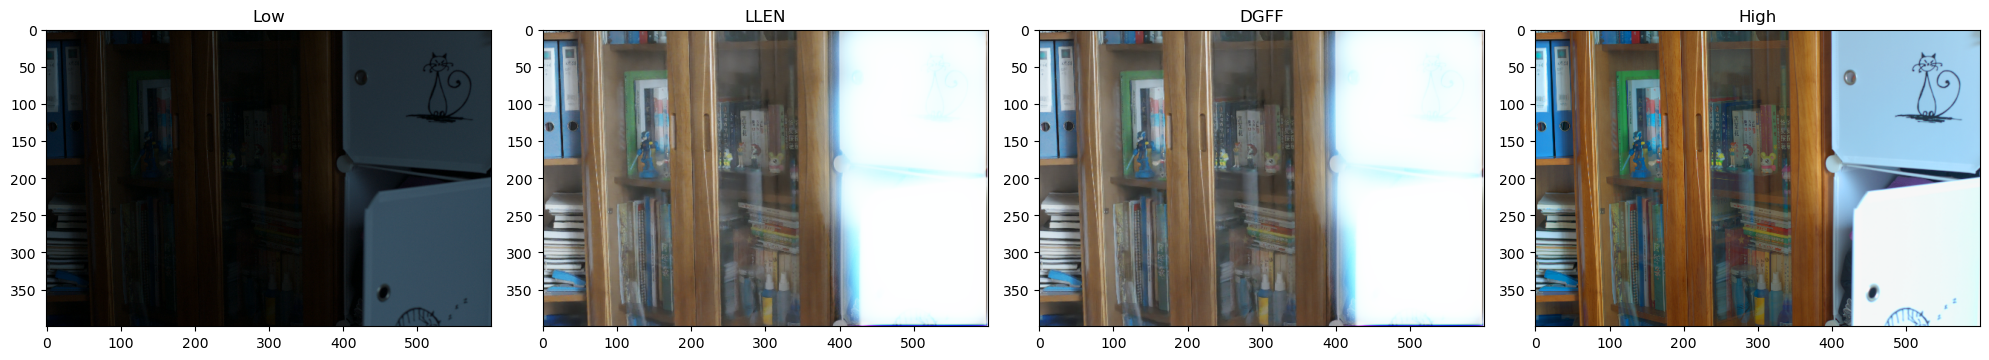

In [14]:
import matplotlib.pyplot as plt

# Fetch a single validation sample (batch size 1)
low, high, fnames = next(iter(val_loader))
low, high = low.to(DEVICE), high.to(DEVICE)

with torch.no_grad():
    enhanced = llen(low)
    p4, p5, p3 = dgff(enhanced)
    enhanced_guided = llen(low, dgff_p5=p5, dgff_p4=p4, dgff_p3=p3)

# Plot the first (only) image
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(low[0].permute(1,2,0).cpu())
axes[0].set_title('Low')
axes[1].imshow(enhanced[0].permute(1,2,0).cpu())
axes[1].set_title('LLEN')
axes[2].imshow(enhanced_guided[0].permute(1,2,0).cpu())
axes[2].set_title('DGFF')
axes[3].imshow(high[0].permute(1,2,0).cpu())
axes[3].set_title('High')
plt.tight_layout()
plt.show()

In [15]:
# (Your existing plotting code here...)
plt.tight_layout()
plt.savefig('qualitative_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig('qualitative_comparison.pdf', bbox_inches='tight')  # Even better for papers
plt.show()

<Figure size 640x480 with 0 Axes>

In [18]:
from ultralytics import YOLO

# llen_weights = './runs/detect/runs/detect/domain_detectors/llen_detector/weights/best.pt'
# dgff_weights = './runs/detect/runs/detect/domain_detectors/dgff_detector/weights/best.pt'

# RAW_WEIGHTS  = './runs/detect/runs/exdark_detector/yolov8n_exdark/weights/best.pt'
llen_weights = './runs/detect/runs/detect/domain_detectors/llen_detector/weights/best.pt'
dgff_weights = './runs/detect/runs/detect/domain_detectors/dgff_detector/weights/best.pt'

model_llen = YOLO(llen_weights)
model_dgff = YOLO(dgff_weights)

# Validate on the corresponding test sets (you have the data.yaml files)
print("LLEN detector val:")
results_llen = model_llen.val(data='detectors/llen/data.yaml', split='test', verbose=False)
print(f"mAP@0.5: {results_llen.box.map50}")

print("\nDGFF detector val:")
results_dgff = model_dgff.val(data='detectors/dgff/data.yaml', split='test', verbose=False)
print(f"mAP@0.5: {results_dgff.box.map50}")

LLEN detector val:
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs


FileNotFoundError: [34m[1mval: [0mError loading data from None
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [21]:
from ultralytics import YOLO
import pandas as pd
import torch

# Paths to your domain‑adapted detectors
llen_weights = './runs/detect/runs/detect/domain_detectors/llen_detector/weights/best.pt'
dgff_weights = './runs/detect/runs/detect/domain_detectors/dgff_detector/weights/best.pt'

# YAML files
llen_yaml = 'detectors/llen/data.yaml'
dgff_yaml = 'detectors/dgff/data.yaml'

# ExDark class names (12 classes)
class_names = ['Bicycle', 'Boat', 'Bottle', 'Bus', 'Car', 'Cat', 'Chair', 'Cup', 
               'Dog', 'Motorbike', 'People', 'Table']

def get_per_class_ap(weights, data_yaml):
    model = YOLO(weights)
    # Use split='val' (or omit split to default to val)
    results = model.val(data=data_yaml, split='val', verbose=False)
    # Get per-class AP@0.5
    ap_per_class = {}
    # results.box.ap is a list of AP values for each class; ap_class_index maps index to class id
    for idx, ap in zip(results.box.ap_class_index, results.box.ap):
        ap_per_class[int(idx)] = ap
    return ap_per_class

# Evaluate
llen_ap_dict = get_per_class_ap(llen_weights, llen_yaml)
dgff_ap_dict = get_per_class_ap(dgff_weights, dgff_yaml)

# Build table
data = {
    'Class': class_names,
    'LLEN': [llen_ap_dict.get(i, 0.0) for i in range(len(class_names))],
    'DGFF': [dgff_ap_dict.get(i, 0.0) for i in range(len(class_names))],
}
df = pd.DataFrame(data)
df['Δ (DGFF - LLEN)'] = df['DGFF'] - df['LLEN']

print("\nPer-class AP@0.5 (LLEN vs DGFF)")
print(df.to_string(index=False, float_format="%.4f"))

# Overall mAP
print(f"\nOverall mAP@0.5:")
print(f"  LLEN: {sum(data['LLEN'])/len(data['LLEN']):.4f}")
print(f"  DGFF: {sum(data['DGFF'])/len(data['DGFF']):.4f}")

Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 367.3±221.8 MB/s, size: 123.4 KB)
val: Scanning /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/domain_datasets/llen/labels/val... 2563 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2563/2563 7.1Kit/s 0.4s0.1s
val: New cache created: /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/domain_datasets/llen/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 161/161 1.8s/it 4:481.8ss
                   all       2563       7117      0.561      0.454      0.469      0.276
Speed: 0.4ms preprocess, 109.0ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /Users/shuvrosankar/miniconda3/MSCS/CVPR/DGFF/runs/detect/val59
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 

In [22]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from ultralytics import YOLO

# Paths to your data YAML files
llen_yaml = 'detectors/llen/data.yaml'
dgff_yaml = 'detectors/dgff/data.yaml'

# Seeds for reproducibility
seeds = [42, 123, 456]

# Storage for results
results = {'seed': [], 'method': [], 'map50': []}

for seed in seeds:
    print(f"\n===== Training with seed {seed} =====")
    
    # ---- Train on LLEN dataset ----
    print("Training LLEN detector...")
    model_llen = YOLO('yolov8n.pt')  # start from COCO pretrained
    model_llen.train(data=llen_yaml, epochs=100, imgsz=640, batch=16, seed=seed, verbose=False, project='runs/seed_llen', name=f'seed_{seed}')
    # Validate
    print("Validating LLEN detector...")
    results_llen = model_llen.val(data=llen_yaml, split='val', verbose=False)
    map50_llen = results_llen.box.map50
    results['seed'].append(seed)
    results['method'].append('LLEN')
    results['map50'].append(map50_llen)
    print(f"  LLEN mAP@0.5: {map50_llen:.4f}")

    # ---- Train on DGFF dataset ----
    print("Training DGFF detector...")
    model_dgff = YOLO('yolov8n.pt')
    model_dgff.train(data=dgff_yaml, epochs=100, imgsz=640, batch=16, seed=seed, verbose=False, project='runs/seed_dgff', name=f'seed_{seed}')
    # Validate
    print("Validating DGFF detector...")
    results_dgff = model_dgff.val(data=dgff_yaml, split='val', verbose=False)
    map50_dgff = results_dgff.box.map50
    results['seed'].append(seed)
    results['method'].append('DGFF')
    results['map50'].append(map50_dgff)
    print(f"  DGFF mAP@0.5: {map50_dgff:.4f}")

# Convert to DataFrame
df_results = pd.DataFrame(results)

# Compute mean and std per method
stats_summary = df_results.groupby('method')['map50'].agg(['mean', 'std']).round(4)
print("\n=== Summary ===")
print(stats_summary)

# Perform paired t-test (LLEN vs DGFF, paired by seed)
llen_maps = df_results[df_results['method']=='LLEN']['map50'].values
dgff_maps = df_results[df_results['method']=='DGFF']['map50'].values
t_stat, p_value = stats.ttest_rel(llen_maps, dgff_maps)
print(f"\nPaired t-test: t = {t_stat:.4f}, p = {p_value:.4f}")

# Save results to CSV
df_results.to_csv('detector_seed_results.csv', index=False)
print("\nResults saved to 'detector_seed_results.csv'")


===== Training with seed 42 =====
Training LLEN detector...
New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=detectors/llen/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('detector_seed_results.csv')
plt.figure(figsize=(6,4))
for method in ['LLEN', 'DGFF']:
    data = df[df['method']==method]['map50']
    plt.plot(data, marker='o', label=method)
plt.xlabel('Seed')
plt.ylabel('mAP@0.5')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('seed_results.png', dpi=150)
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from scipy import stats
from ultralytics import YOLO

# ─────────────────────────────────────────────────────────────────────────
# Fixes vs. your original script:
#   1. device='mps' explicit (your run used CPU -> 42h for ONE 100-epoch
#      run; MPS should be dramatically faster on an M4).
#   2. epochs=50, matching your paper's documented detector-training
#      protocol (Section 3.8/4.1) -- 100 epochs breaks comparability with
#      your reported 0.469/0.474 numbers, not just doubles compute.
#   3. CALIBRATE=True runs seed 42 only first and compares against your
#      paper's reported numbers before committing to the full 3-seed loop.
#      Don't skip this -- your last run's LLEN result (0.446) didn't match
#      the paper's 0.469, which needs to be understood before multi-seed
#      numbers mean anything.
#   4. Incremental CSV save after every run, not just at the end.
# ─────────────────────────────────────────────────────────────────────────

llen_yaml = 'detectors/llen/data.yaml'
dgff_yaml = 'detectors/dgff/data.yaml'

EPOCHS = 50                 # matches paper protocol -- do not change without
                             # also noting the deviation in the paper
CALIBRATE = True            # run seed 42 only first, sanity-check, then stop
PAPER_LLEN_MAP50 = 0.469
PAPER_DGFF_MAP50 = 0.474
CALIBRATION_TOLERANCE = 0.01  # how close a rerun should land to count as "reproduced"

seeds = [42, 123, 456]
results_path = 'detector_seed_results.csv'

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cpu':
    print("WARNING: MPS not available -- this will be very slow (see your "
          "last run: 42h for one 100-epoch job). Fix your torch/MPS setup "
          "before running the full loop.")


def train_and_val(weights, data_yaml, seed, project, epochs):
    model = YOLO(weights)
    model.train(data=data_yaml, epochs=epochs, imgsz=640, batch=16,
                seed=seed, device=device, verbose=False,
                project=project, name=f'seed_{seed}', exist_ok=True)
    val_results = model.val(data=data_yaml, split='val', device=device, verbose=False)
    return val_results.box.map50


def append_result(path, row):
    df_row = pd.DataFrame([row])
    header = not os.path.exists(path)
    df_row.to_csv(path, mode='a', header=header, index=False)


# ── Calibration pass ────────────────────────────────────────────────────
if CALIBRATE:
    print("\n===== CALIBRATION: seed 42 only, checking against paper numbers =====")

    map50_llen = train_and_val('yolov8n.pt', llen_yaml, 42, 'runs/seed_llen', EPOCHS)
    append_result(results_path, {'seed': 42, 'method': 'LLEN', 'map50': map50_llen})
    llen_diff = abs(map50_llen - PAPER_LLEN_MAP50)
    print(f"  LLEN mAP@0.5 = {map50_llen:.4f}  (paper: {PAPER_LLEN_MAP50}, "
          f"diff: {llen_diff:.4f})")

    map50_dgff = train_and_val('yolov8n.pt', dgff_yaml, 42, 'runs/seed_dgff', EPOCHS)
    append_result(results_path, {'seed': 42, 'method': 'DGFF', 'map50': map50_dgff})
    dgff_diff = abs(map50_dgff - PAPER_DGFF_MAP50)
    print(f"  DGFF mAP@0.5 = {map50_dgff:.4f}  (paper: {PAPER_DGFF_MAP50}, "
          f"diff: {dgff_diff:.4f})")

    if llen_diff > CALIBRATION_TOLERANCE or dgff_diff > CALIBRATION_TOLERANCE:
        print(f"\nSTOP: calibration numbers differ from the paper by more than "
              f"{CALIBRATION_TOLERANCE}. Before running seeds 123/456, figure out "
              f"why -- likely candidates: dataset split mismatch, ultralytics "
              f"version drift (you're on 8.4.24), or a hyperparameter that was "
              f"set explicitly in the original run and is now using a different "
              f"default. Running more seeds on top of an unreproduced baseline "
              f"won't give you a trustworthy significance result.")
        raise SystemExit(1)
    else:
        print("\nCalibration OK -- numbers are close enough to the paper to trust "
              "the rest of the pipeline. Proceeding to remaining seeds.")
    remaining_seeds = [s for s in seeds if s != 42]
else:
    remaining_seeds = seeds

# ── Remaining seeds ─────────────────────────────────────────────────────
for seed in remaining_seeds:
    print(f"\n===== Training with seed {seed} =====")

    print("Training LLEN detector...")
    map50_llen = train_and_val('yolov8n.pt', llen_yaml, seed, 'runs/seed_llen', EPOCHS)
    append_result(results_path, {'seed': seed, 'method': 'LLEN', 'map50': map50_llen})
    print(f"  LLEN mAP@0.5: {map50_llen:.4f}")

    print("Training DGFF detector...")
    map50_dgff = train_and_val('yolov8n.pt', dgff_yaml, seed, 'runs/seed_dgff', EPOCHS)
    append_result(results_path, {'seed': seed, 'method': 'DGFF', 'map50': map50_dgff})
    print(f"  DGFF mAP@0.5: {map50_dgff:.4f}")

# ── Analysis ─────────────────────────────────────────────────────────────
df_results = pd.read_csv(results_path)

stats_summary = df_results.groupby('method')['map50'].agg(['mean', 'std', 'count']).round(4)
print("\n=== Summary ===")
print(stats_summary)

llen_maps = df_results[df_results['method'] == 'LLEN'].sort_values('seed')['map50'].values
dgff_maps = df_results[df_results['method'] == 'DGFF'].sort_values('seed')['map50'].values

if len(llen_maps) == len(dgff_maps) and len(llen_maps) >= 2:
    t_stat, p_value = stats.ttest_rel(llen_maps, dgff_maps)
    print(f"\nPaired t-test: t = {t_stat:.4f}, p = {p_value:.4f}")
    print(f"n = {len(llen_maps)} seeds -- with n<5 this test has very low power. "
          f"A non-significant p-value here means 'not enough data to tell', not "
          f"'no effect'. Report the raw per-seed numbers and mean+/-std alongside "
          f"the p-value rather than leaning on significance alone.")
else:
    print("\nSkipping paired t-test -- unequal or insufficient runs per method.")

print(f"\nResults saved incrementally to '{results_path}'")

Using device: mps

===== CALIBRATION: seed 42 only, checking against paper numbers =====
New https://pypi.org/project/ultralytics/8.4.115 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=detectors/llen/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, 

In [3]:
from ultralytics import YOLO

# Candidates found on disk, with a guess at what each one is based on path naming.
# Update the yaml paths if yours differ.
candidates = [
    ('checkpoints/best.pt',
     None,  # not a detector -- expect this to fail to load as YOLO, or be meaningless
     'Guess: LLEN enhancement network (Phase 1), not a detector'),

    ('runs/detect/runs/detect/domain_detectors/llen_detector/weights/best.pt',
     'detectors/llen/data.yaml',
     'Guess: LLEN-only domain-matched detector (paper reports mAP@0.5 = 0.469)'),

    ('runs/detect/runs/detect/domain_detectors/dgff_detector/weights/best.pt',
     'detectors/dgff/data.yaml',
     'Guess: DGFF domain-matched detector (paper reports mAP@0.5 = 0.474)'),
]

PAPER_NUMBERS = {
    'detectors/llen/data.yaml': 0.469,
    'detectors/dgff/data.yaml': 0.474,
}

print(f"{'Checkpoint':<75} {'mAP@0.5':>10} {'Paper':>8} {'Diff':>8}")
print("-" * 105)

for path, yaml, note in candidates:
    print(f"\n{note}")
    if yaml is None:
        try:
            m = YOLO(path)
            print(f"  Loaded as YOLO OK -- unexpected if this is really the "
                  f"enhancement network. Check what it actually is.")
        except Exception as e:
            print(f"  Failed to load as a YOLO detector ({type(e).__name__}: {e}) "
                  f"-- confirms this is NOT a detector checkpoint. Expected.")
        continue

    try:
        m = YOLO(path)
        r = m.val(data=yaml, split='test', verbose=False)
        map50 = r.box.map50
        paper = PAPER_NUMBERS.get(yaml)
        diff = abs(map50 - paper) if paper is not None else None
        diff_str = f"{diff:.4f}" if diff is not None else "n/a"
        print(f"  {path:<73} {map50:>10.4f} {paper:>8} {diff_str:>8}")
        if diff is not None and diff < 0.01:
            print(f"  -> MATCH: this is very likely the checkpoint used in the paper.")
        elif diff is not None:
            print(f"  -> Does not match closely. Either wrong file, wrong yaml/split, "
                  f"or this checkpoint predates your final reported run.")
    except Exception as e:
        print(f"  Failed: {type(e).__name__}: {e}")

Checkpoint                                                                     mAP@0.5    Paper     Diff
---------------------------------------------------------------------------------------------------------

Guess: LLEN enhancement network (Phase 1), not a detector
  Failed to load as a YOLO detector (KeyError: 'model') -- confirms this is NOT a detector checkpoint. Expected.

Guess: LLEN-only domain-matched detector (paper reports mAP@0.5 = 0.469)
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
  Failed: FileNotFoundError: val: Error loading data from None
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

Guess: DGFF domain-matched detector (paper reports mAP@0.5 = 0.474)
Ultralytics 8.4.24 🚀 Python-3.14.2 torch-2.10.0 CPU (Apple M4)
Model summary (fused): 73 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
  Failed: FileNotFoundError: val: Error loading da